# 🧪 Lab: Write Your Own Explainable AI (XAI) Methods

**Dataset:** BloodMNIST: coloured microscope images of blood cells, 8 classes, 64 × 64 pixels  
**Model:** a small CNN (given to you)  
**Your job:** write the code for 7 XAI methods, then measure how good they are.

| Task | What you write | Marks |
|---|---|---|
| 1 | Saliency Map | 4 |
| 2 | Guided Backpropagation | 4 |
| 3 | CAM | 4 |
| 4 | Grad-CAM | 4 |
| 5 | Grad-CAM++ | 4 |
| 6 | LIME | 4 |
| 7 | SHAP | 4 |
| 8 | Side-by-side comparison figure | 2 |
| 9 | Quantitative evaluation (Deletion, Insertion, Average Drop) | 10 |
| 10 | Written questions | 10 |
| **Total** | | **50** |

### Rules
- The cells marked **GIVEN** are ready. Just run them.
- Write your code where you see `# YOUR CODE HERE`. Do not change the function names or inputs.
- Every XAI function must return a **NumPy heatmap of shape (64, 64) with values between 0 and 1**.
- After each task, run the **CHECK** cell. If it prints ✅, your output has the right shape.
- Use Google Colab with a GPU (Runtime → Change runtime type → GPU). A CPU also works, but it is slower.
- **Submit:** `RollNo_Name_XAI_Lab.ipynb` with all outputs shown.

## Part A — Setup (GIVEN)

In [ ]:
%pip install -q medmnist lime shap torch torchvision pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import medmnist
from medmnist import INFO

torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cpu


### Load BloodMNIST (GIVEN)

8 blood-cell classes: basophil, eosinophil, erythroblast, immature granulocytes, lymphocyte, monocyte, neutrophil, platelet.

Using 28x28 mirror, resized to 64x64: C:\Users\pc\.medmnist\bloodmnist_28_hf.npz
11959 train | 3421 test | ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


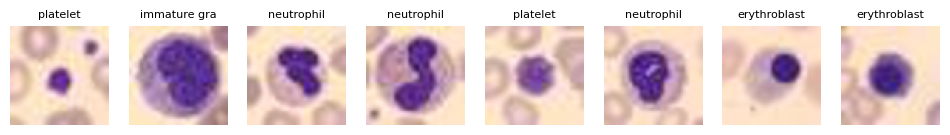

In [ ]:
import hashlib, urllib.request
from pathlib import Path
from PIL import Image

IMG_SIZE = 64
info = INFO["bloodmnist"]
class_names = [info["label"][str(i)] for i in range(len(info["label"]))]
num_classes = len(class_names)

root = Path.home() / ".medmnist"
root.mkdir(exist_ok=True)

# Source A: official 64x64 file (only used if you already downloaded it from Zenodo)
f64 = root / "bloodmnist_64.npz"
MD5_64 = info["MD5_64"]
# Source B: Hugging Face mirror of the official file (28x28, ~35 MB) -> resized to 64x64
f28 = root / "bloodmnist_28_hf.npz"
URL_28 = "https://huggingface.co/datasets/albertvillanova/medmnist-v2/resolve/0472595ab51916346dc4ad40f7b77551f2171403/data/bloodmnist.npz"
SHA_28 = "062023e186f537e26b3c21ea3b2614ddfc475e8a14825dfd20663bbb7e37bddc"

def file_hash(path, algo):
    h = hashlib.new(algo)
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

if f64.exists() and file_hash(f64, "md5") == MD5_64:
    data_file, need_resize = f64, False
    print("Using official 64x64 file:", f64)
else:
    if not (f28.exists() and file_hash(f28, "sha256") == SHA_28):
        if f28.exists():
            f28.unlink()
        print("Downloading BloodMNIST from Hugging Face (~35 MB)...")
        req = urllib.request.Request(URL_28, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=120) as r, open(f28, "wb") as out:
            while True:
                chunk = r.read(1 << 20)
                if not chunk:
                    break
                out.write(chunk)
        if file_hash(f28, "sha256") != SHA_28:
            f28.unlink()
            raise RuntimeError("Downloaded file is corrupted. Run this cell again.")
    data_file, need_resize = f28, True
    print("Using 28x28 mirror, resized to 64x64:", f28)

transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize([0.5] * 3, [0.5] * 3)])   # pixels -> [-1, 1]

class BloodMNISTData(torch.utils.data.Dataset):
    def __init__(self, npz_path, split, transform, resize):
        d = np.load(npz_path)
        imgs, self.labels = d[f"{split}_images"], d[f"{split}_labels"]     # labels: (N, 1)
        if resize:
            imgs = np.stack([np.array(Image.fromarray(im).resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)) for im in imgs])
        self.imgs, self.transform = imgs, transform
    def __len__(self):
        return len(self.imgs)
    def __getitem__(self, i):
        return self.transform(self.imgs[i]), self.labels[i]

train_ds = BloodMNISTData(data_file, "train", transform, need_resize)
test_ds  = BloodMNISTData(data_file, "test",  transform, need_resize)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=256)
print(len(train_ds), "train |", len(test_ds), "test |", class_names)

def to_image(t):
    # normalised tensor (3,H,W) -> image (H,W,3) in [0,1] for plotting
    return np.clip(t.detach().cpu().numpy().transpose(1, 2, 0) * 0.5 + 0.5, 0, 1)

plt.figure(figsize=(12, 2))
for i in range(8):
    img, lab = train_ds[i]
    plt.subplot(1, 8, i + 1); plt.imshow(to_image(img)); plt.title(class_names[int(lab[0])][:12], fontsize=8); plt.axis("off")
plt.show()

### A small CNN (GIVEN)

```
Input (3×64×64)
 → Conv 32 → ReLU → MaxPool      (32×32)
 → Conv 64 → ReLU → MaxPool      (16×16)
 → Conv 128 → ReLU               (16×16)   ← model.features  (last conv feature maps A^k)
 → Global Average Pooling        (128)
 → fc: Linear(128 → 8)                     ← model.fc  (weights w_k^c used by CAM)
```

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        return self.fc(self.gap(self.features(x)).flatten(1))

model = SimpleCNN(num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(5):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.squeeze(1).long().to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(model(xb), yb)
        loss.backward()
        optimizer.step()
    print(f"epoch {epoch+1}  loss {loss.item():.3f}")

model.eval()
with torch.no_grad():
    correct = sum((model(xb.to(device)).argmax(1).cpu() == yb.squeeze(1)).sum().item() for xb, yb in test_loader)
print(f"Test accuracy: {100 * correct / len(test_ds):.1f}%")

epoch 1  loss 1.395
epoch 2  loss 0.823
epoch 3  loss 0.608
epoch 4  loss 0.760
epoch 5  loss 0.624
Test accuracy: 79.1%


### Pick one image and some helpers (GIVEN)

In [ ]:
labels = test_ds.labels.squeeze()
idx = 0
x = test_ds[idx][0].unsqueeze(0).to(device)       # (1, 3, 64, 64)
image = to_image(x[0])
with torch.no_grad():
    probs = F.softmax(model(x), 1)[0]
pred_class = int(probs.argmax())
print("True:", class_names[labels[idx]], "| Predicted:", class_names[pred_class], f"({probs[pred_class].item():.2f})")

def normalize(a):
    a = np.asarray(a, dtype=np.float32)
    a = a - a.min()
    return a / (a.max() + 1e-8)

def upsample(t):
    # small torch map (h, w) -> numpy (64, 64) in [0, 1]
    t = torch.as_tensor(t, dtype=torch.float32).detach().cpu()
    return normalize(F.interpolate(t[None, None], size=(IMG_SIZE, IMG_SIZE), mode="bilinear")[0, 0].numpy())

def show(heat, title):
    plt.figure(figsize=(7, 2.5))
    plt.subplot(1, 3, 1); plt.imshow(image); plt.title("Image"); plt.axis("off")
    plt.subplot(1, 3, 2); plt.imshow(heat, cmap="jet"); plt.title(title); plt.axis("off")
    plt.subplot(1, 3, 3); plt.imshow(image); plt.imshow(heat, cmap="jet", alpha=0.5); plt.title("Overlay"); plt.axis("off")
    plt.show()

def check(heat, name):
    ok = isinstance(heat, np.ndarray) and heat.shape == (IMG_SIZE, IMG_SIZE) and heat.min() >= 0 and heat.max() <= 1 + 1e-6
    print(("✅ " if ok else "❌ ") + name + (" looks correct" if ok else " must return a (64, 64) numpy array in [0, 1]"))
    if ok: show(heat, name)

# Hook helper: get the feature maps A (128,16,16) and their gradients G for class `cls`
def get_A_and_G(m, x, cls):
    store = {}
    def hook(module, inp, out):
        store["A"] = out
        out.register_hook(lambda g: store.update(G=g))
    h = m.features.register_forward_hook(hook)
    m.zero_grad()
    m(x)[0, cls].backward()
    h.remove()
    return store["A"][0].detach(), store["G"][0].detach()

True: immature granulocytes(myelocytes, metamyelocytes and promyelocytes) | Predicted: immature granulocytes(myelocytes, metamyelocytes and promyelocytes) (0.66)


---
## Part B: Write the XAI methods

### Task 1: Saliency Map (4 marks)
$$\text{Saliency}(i,j) = \max_{c}\left|\frac{\partial y^{cls}}{\partial x_{c,i,j}}\right|$$
**Steps:** (1) copy `x` and make it require gradients, (2) forward pass and take the score of `cls`, (3) `backward()`, (4) take the absolute value of the input gradient, then the max over the 3 colour channels, (5) `normalize`.

✅ Saliency looks correct


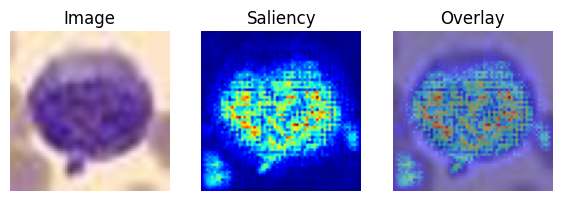

In [ ]:
def saliency(m, x, cls):
    xi = x.clone().detach().requires_grad_(True)      # (1) copy x, track gradients
    m.zero_grad()
    score = m(xi)[0, cls]                             # (2) score of class cls
    score.backward()                                  # (3) backward
    g = xi.grad[0].abs().max(dim=0)[0]                # (4) abs, then max over 3 colour channels -> (64, 64)
    heat = normalize(g.cpu().numpy())                 # (5) scale to [0, 1]
    return heat

check(saliency(model, x, pred_class), "Saliency")

### Task 2: Guided Backpropagation (4 marks)
Like saliency, but at every ReLU only **positive** gradients may flow backwards.

**Steps:** (1) make a copy of the model with `copy.deepcopy`, (2) on every `nn.ReLU` register a **full backward hook** that returns `(torch.clamp(grad_in[0], min=0),)`, (3) compute the input gradient as in Task 1, (4) abs, max over channels, normalize.

✅ Guided Backprop looks correct


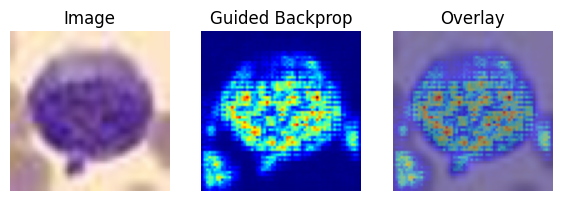

In [ ]:
def guided_backprop(m, x, cls):
    gm = copy.deepcopy(m)                             # (1) work on a copy, so the original model is untouched
    gm.eval()

    def relu_hook(module, grad_in, grad_out):
        return (torch.clamp(grad_in[0], min=0),)      # (2) only positive gradients flow back

    for module in gm.modules():
        if isinstance(module, nn.ReLU):
            module.register_full_backward_hook(relu_hook)

    xi = x.clone().detach().requires_grad_(True)      # (3) input gradient, same as Task 1
    gm.zero_grad()
    gm(xi)[0, cls].backward()
    g = xi.grad[0].abs().max(dim=0)[0]                # (4) abs, max over channels
    heat = normalize(g.cpu().numpy())                 #     normalize
    return heat

check(guided_backprop(model, x, pred_class), "Guided Backprop")

### Task 3: CAM (4 marks)
$$\text{CAM}^{c} = \text{ReLU}\Big(\sum_k w_k^{c} A^k\Big)$$
**Steps:** (1) get `A` from `get_A_and_G`, (2) take the weights `m.fc.weight[cls]` (shape 128), (3) weighted sum over the 128 maps, (4) ReLU, (5) `upsample` to 64 × 64.

✅ CAM looks correct


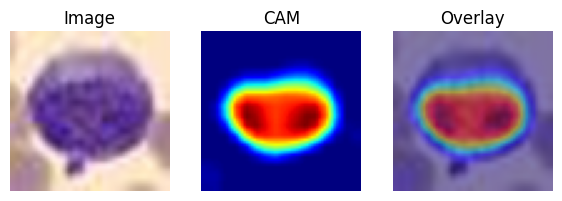

In [ ]:
def cam(m, x, cls):
    A, _ = get_A_and_G(m, x, cls)                     # (1) feature maps A: (128, 16, 16)
    w = m.fc.weight[cls].detach()                     # (2) class weights: (128,)
    c = (w[:, None, None] * A).sum(dim=0)             # (3) weighted sum over the 128 maps -> (16, 16)
    c = F.relu(c)                                     # (4) ReLU
    heat = upsample(c)                                # (5) resize to 64 x 64 and scale to [0, 1]
    return heat

check(cam(model, x, pred_class), "CAM")

### Task 4: Grad-CAM (4 marks)
$$\alpha_k^c = \frac{1}{Z}\sum_{i,j}\frac{\partial y^c}{\partial A^k_{ij}} \qquad \text{Grad-CAM}^c = \text{ReLU}\Big(\sum_k \alpha_k^c A^k\Big)$$
**Steps:** (1) get `A, G`, (2) `alpha` = mean of `G` over height and width, (3) weighted sum, ReLU, upsample.

✅ Grad-CAM looks correct


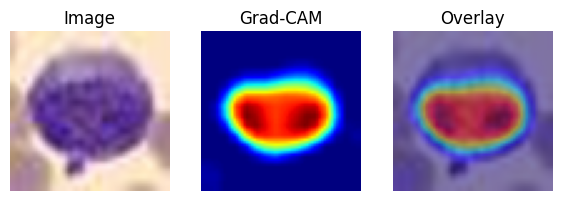

In [ ]:
def grad_cam(m, x, cls):
    A, G = get_A_and_G(m, x, cls)                     # (1) feature maps and their gradients
    alpha = G.mean(dim=(1, 2))                        # (2) alpha_k = mean of gradient over height and width
    c = (alpha[:, None, None] * A).sum(dim=0)         # (3) weighted sum of feature maps
    c = F.relu(c)                                     #     ReLU
    heat = upsample(c)                                #     resize to 64 x 64
    return heat

check(grad_cam(model, x, pred_class), "Grad-CAM")

### Task 5: Grad-CAM++ (4 marks)
$$a_{ij}^{k} = \frac{g_{ij}^2}{2g_{ij}^2 + \sum_{a,b}A^k_{ab}\,g_{ij}^3}\qquad w_k^c = \sum_{i,j} a^k_{ij}\,\text{ReLU}(g_{ij}) \qquad \text{Grad-CAM++}^c=\text{ReLU}\Big(\sum_k w_k^c A^k\Big)$$
(add `1e-8` to the denominator to avoid division by zero)

✅ Grad-CAM++ looks correct


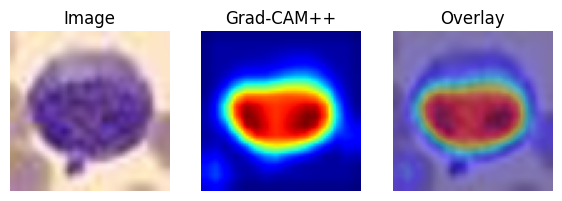

In [ ]:
def grad_cam_pp(m, x, cls):
    A, G = get_A_and_G(m, x, cls)                     # A, G: (128, 16, 16)
    sumA = A.sum(dim=(1, 2), keepdim=True)            # sum over all positions of each map: (128, 1, 1)
    alpha = G ** 2 / (2 * G ** 2 + sumA * G ** 3 + 1e-8)   # pixel-wise weights a_ij^k
    w = (alpha * F.relu(G)).sum(dim=(1, 2))           # channel weights w_k^c: (128,)
    c = F.relu((w[:, None, None] * A).sum(dim=0))     # weighted sum + ReLU
    heat = upsample(c)                                # resize to 64 x 64
    return heat

check(grad_cam_pp(model, x, pred_class), "Grad-CAM++")

### Task 6: LIME (4 marks)
**Steps:**
1. Write `predict_fn(images)`. It gets a NumPy batch `(N, 64, 64, 3)` in [0, 1] and must return class **probabilities** `(N, 8)`. Hint: apply `transform` to each image, stack them, run the model, then softmax.
2. Call `lime_image.LimeImageExplainer().explain_instance(...)` with `labels=(cls,)`, `top_labels=None`, `num_samples=500`, `segmentation_fn=segmenter`, `random_seed=0`.
3. Make a heatmap: every superpixel gets its **positive** LIME weight. Hint: `weights = dict(exp.local_exp[cls])`, and `exp.segments` tells you which superpixel each pixel belongs to.

  0%|          | 0/500 [00:00<?, ?it/s]

✅ LIME looks correct


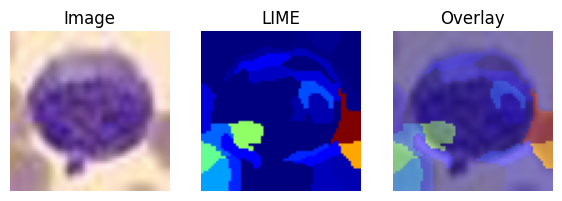

In [ ]:
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm
segmenter = SegmentationAlgorithm("slic", n_segments=50, compactness=10)

def lime_explain(m, x, cls):
    # (1) prediction function: NumPy (N, 64, 64, 3) in [0, 1]  ->  probabilities (N, 8)
    def predict_fn(images):
        batch = torch.stack([transform(img.astype(np.float32)) for img in images]).float().to(device)
        with torch.no_grad():
            return F.softmax(m(batch), dim=1).cpu().numpy()

    img = to_image(x[0]).astype(np.float64)           # the image as (64, 64, 3) in [0, 1]

    # (2) run LIME
    exp = lime_image.LimeImageExplainer().explain_instance(
        img, predict_fn, labels=(cls,), top_labels=None,
        num_samples=500, segmentation_fn=segmenter, random_seed=0)

    # (3) each superpixel gets its positive LIME weight
    weights = dict(exp.local_exp[cls])
    heat = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    for seg_id, w in weights.items():
        heat[exp.segments == seg_id] = max(w, 0)
    return normalize(heat)

check(lime_explain(model, x, pred_class), "LIME")

### Task 7: SHAP (4 marks)
**Steps:**
1. Make a `background` tensor from 50 training images.
2. `shap.GradientExplainer(m, background).shap_values(x, nsamples=100)`
3. Pick the values of class `cls`. **Careful:** new SHAP versions return shape `(1, 3, H, W, classes)`, older ones return a list `(classes)[1, 3, H, W]`.
4. Sum over the 3 colour channels, keep only positive values, normalize.

✅ SHAP looks correct


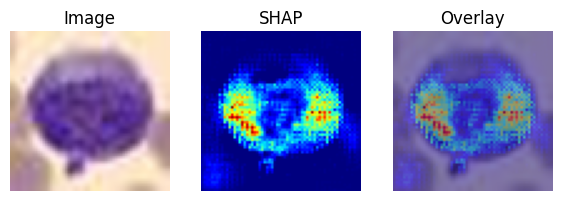

In [ ]:
import shap
background = torch.stack([train_ds[i][0] for i in range(50)]).to(device)

def shap_explain(m, x, cls):
    explainer = shap.GradientExplainer(m, background)
    sv = explainer.shap_values(x, nsamples=100)

    # pick the values of class cls (handles both old and new SHAP output formats)
    if isinstance(sv, list):                          # old: list (classes) of [1, 3, H, W]
        v = np.asarray(sv[cls])[0]                    # -> (3, H, W)
    else:
        sv = np.asarray(sv)
        if sv.ndim == 5 and sv.shape[-1] == num_classes:   # new: (1, 3, H, W, classes)
            v = sv[0, ..., cls]                       # -> (3, H, W)
        else:                                         # fallback: (classes, 1, 3, H, W)
            v = sv[cls, 0]

    heat = v.sum(axis=0)                              # sum over the 3 colour channels -> (H, W)
    heat = np.clip(heat, 0, None)                     # keep only positive values
    return normalize(heat)

check(shap_explain(model, x, pred_class), "SHAP")

### Task 8: Compare all methods (2 marks)
Make **one figure with 8 panels**: the original image and the 7 heatmaps (overlaid on the image), each with a title.

In [ ]:
METHODS = {"Saliency": saliency, "Guided BP": guided_backprop, "CAM": cam, "Grad-CAM": grad_cam,
           "Grad-CAM++": grad_cam_pp, "LIME": lime_explain, "SHAP": shap_explain}

  0%|          | 0/500 [00:00<?, ?it/s]

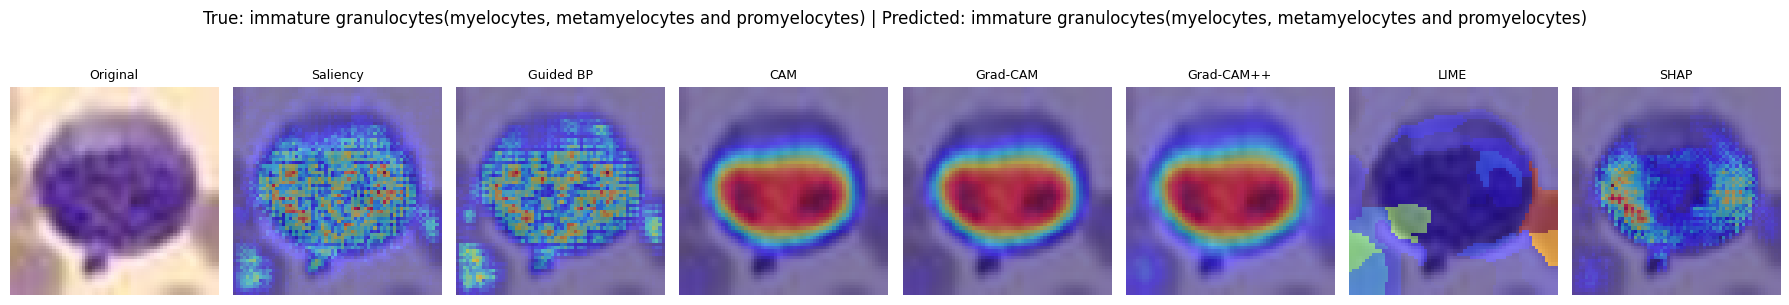

In [ ]:
fig, axes = plt.subplots(1, 8, figsize=(18, 3))
axes[0].imshow(image); axes[0].set_title("Original", fontsize=9); axes[0].axis("off")
for ax, (name, fn) in zip(axes[1:], METHODS.items()):
    heat = fn(model, x, pred_class)
    ax.imshow(image)
    ax.imshow(heat, cmap="jet", alpha=0.5)
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.suptitle(f"True: {class_names[labels[idx]]} | Predicted: {class_names[pred_class]}", y=1.05)
plt.tight_layout()
plt.show()

---
## Part C: Quantitative evaluation (10 marks)

### Task 9a: Deletion and Insertion AUC (4 marks)
Sort the pixels from **most** to **least** important (using the heatmap). In `steps = 20` steps:
- **Deletion:** set the top $k\%$ of pixels to 0 (the mean colour) and record the probability of `cls`. **Lower AUC is better.**
- **Insertion:** start from a **blurred** image and paste back the top $k\%$ original pixels. **Higher AUC is better.**

AUC = mean of the probabilities (trapezoid rule: `((p[:-1] + p[1:]) / 2).mean()`).  
Blur hint: `transforms.functional.gaussian_blur(x, kernel_size=15, sigma=5)`.

In [ ]:
def deletion_insertion(m, x, heat, cls, steps=20):
    H = W = IMG_SIZE
    n = H * W
    order = np.argsort(-np.asarray(heat).flatten(), kind="stable")   # most important pixel first
    order = torch.as_tensor(order.copy(), device=x.device)
    blurred = transforms.functional.gaussian_blur(x, kernel_size=15, sigma=5)

    del_p, ins_p = [], []
    with torch.no_grad():
        for s in range(steps + 1):
            k = int(round(n * s / steps))             # number of top pixels (0% ... 100%)
            mask = torch.zeros(n, device=x.device)
            mask[order[:k]] = 1
            mask = mask.view(1, 1, H, W)

            x_del = x * (1 - mask)                    # Deletion: top-k pixels -> 0 (mean colour)
            x_ins = blurred * (1 - mask) + x * mask   # Insertion: blurred image + top-k original pixels

            del_p.append(F.softmax(m(x_del), 1)[0, cls].item())
            ins_p.append(F.softmax(m(x_ins), 1)[0, cls].item())

    del_p, ins_p = np.array(del_p), np.array(ins_p)
    del_auc = float(((del_p[:-1] + del_p[1:]) / 2).mean())
    ins_auc = float(((ins_p[:-1] + ins_p[1:]) / 2).mean())
    return del_auc, ins_auc

print(deletion_insertion(model, x, grad_cam(model, x, pred_class), pred_class))

(0.05453382881714788, 0.6260844990611076)


### Task 9b: Average Drop (2 marks)
Keep only the explained region: $x' = x \odot M$ (multiply the image by the heatmap).
With $Y$ = original probability and $O$ = probability on $x'$:
$$\text{Drop} = 100\cdot\frac{\max(0, Y-O)}{Y}\qquad(\text{lower is better})$$

In [ ]:
def average_drop(m, x, heat, cls):
    M = torch.as_tensor(np.asarray(heat), dtype=torch.float32, device=x.device)[None, None]   # (1, 1, 64, 64)
    x_masked = x * M                                  # keep only the explained region
    with torch.no_grad():
        Y = F.softmax(m(x), 1)[0, cls].item()         # original probability
        O = F.softmax(m(x_masked), 1)[0, cls].item()  # probability on x'
    drop = 100 * max(0.0, Y - O) / (Y + 1e-8)
    return drop

print(average_drop(model, x, grad_cam(model, x, pred_class), pred_class))

0.0


### Task 9c: Evaluate on 20 test images (4 marks)
For 20 test images and every method: compute the heatmap for the **predicted** class, then Deletion AUC, Insertion AUC and Average Drop.
Show a table of the **mean** for each method, and a bar chart for each metric.

In [ ]:
N_IMAGES = 20
rows = []
for idx in range(N_IMAGES):
    xk = test_ds[idx][0].unsqueeze(0).to(device)
    with torch.no_grad():
        cls = int(model(xk).argmax(1))                # predicted class
    for name, fn in METHODS.items():
        heat = fn(model, xk, cls)
        d_auc, i_auc = deletion_insertion(model, xk, heat, cls)
        drop = average_drop(model, xk, heat, cls)
        rows.append({"Method": name, "Deletion AUC ⬇": d_auc, "Insertion AUC ⬆": i_auc, "Avg Drop % ⬇": drop})
    print(f"image {idx + 1}/{N_IMAGES} done", end="\r")

results = pd.DataFrame(rows).groupby("Method", sort=False).mean()
results

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

,Deletion AUC ⬇,Insertion AUC ⬆,Avg Drop % ⬇
Method,,,
Saliency,0.088611,0.642171,75.897190
Guided BP,0.079457,0.632825,74.729567
CAM,0.139658,0.678539,31.013481
Grad-CAM,0.139658,0.678539,31.013482
Grad-CAM++,0.088575,0.626667,57.704987
LIME,0.356563,0.662596,83.192284
SHAP,0.171048,0.722412,80.085944


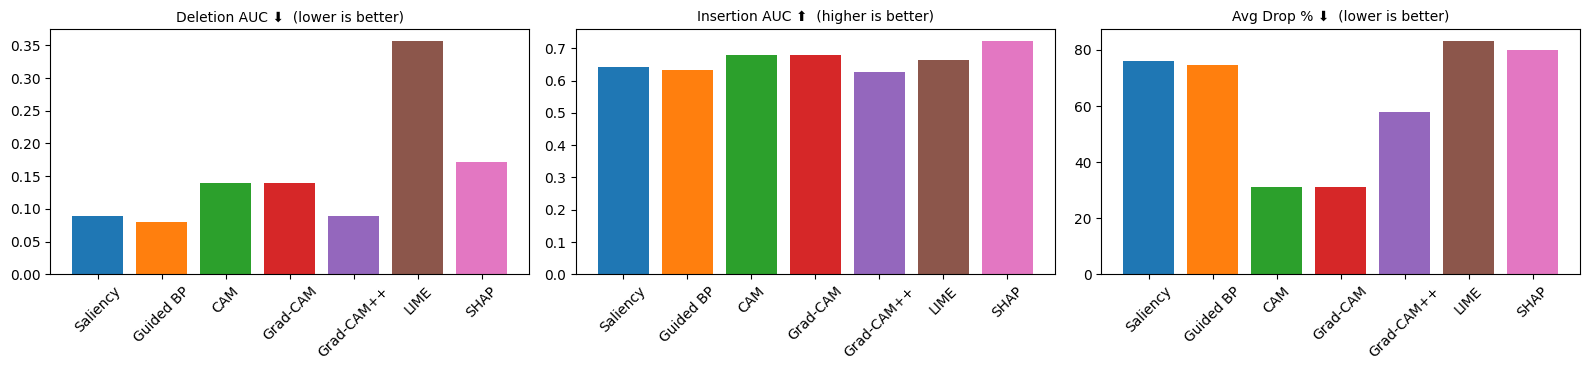

In [ ]:
metrics = [("Deletion AUC ⬇", "lower is better"), ("Insertion AUC ⬆", "higher is better"), ("Avg Drop % ⬇", "lower is better")]
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, (col, note) in zip(axes, metrics):
    ax.bar(results.index, results[col], color=plt.cm.tab10(np.arange(len(results))))
    ax.set_title(f"{col}  ({note})", fontsize=10)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**✍ Your answers:**

1. No single winner. Guided BP is best on Deletion, SHAP on Insertion, and CAM/Grad-CAM on Average Drop.

2. CAM and Grad-CAM are identical. With global average pooling followed by one linear layer, the Grad-CAM weights equal the CAM weights, so the heatmaps and scores match.

3. Pixel-gradient methods (Saliency, Guided BP) are good at Deletion because they pick sharp, important pixels. But their heatmaps are noisy and scattered, so keeping only that region gives a large Average Drop (about 75%).

4. CAM/Grad-CAM give smooth region-level maps, so the region they keep preserves the prediction best

5. LIME is weakest on Deletion (0.357). It uses coarse superpixels and only 500 random samples, so its ranking of pixels is rough and can vary between runs. SHAP is best on Insertion, meaning the pixels it ranks first restore the prediction fastest.